# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


In [11]:
import numpy as np

def storage_modulus(omega, G, t, integration_points=5000):
    """
    TRAPEZOID: Compute the storage modulus for a given frequency, G(t), and number of integration points.
    Parameters:
    omega : float
        Frequency at which to compute the storage modulus.
    G : array_like
        Relaxation modulus values at times t.
    t : array_like
        Time values corresponding to G.
    integration_points : int
        Number of points to use in the numerical integration.
    """

    # Resample G(t) onto a finer grid for integration
    t_int = np.linspace(t[0], t[-1], integration_points)
    G_int = np.interp(t_int, t, G)

    # print(len(t_int), len(G_int))

    integrand = G_int * np.sin(omega * t_int)
    # print(omega * t_int)
    # print(np.sin(omega * t_int))
    # print(integrand)
    # print(np.trapezoid(integrand, t_int))
    return omega * np.trapz(integrand, t_int)

def loss_modulus(omega, G, t, integration_points=5000):
    """
    TRAPEZOID: Compute the loss modulus for a given frequency, G(t), and number of integration points.
    Parameters:
    omega : float
        Frequency at which to compute the loss modulus.
    G : array_like
        Relaxation modulus values at times t.
    t : array_like
        Time values corresponding to G.
    integration_points : int
        Number of points to use in the numerical integration.
    """

    # Resample G(t) onto a finer grid for integration
    t_int = np.linspace(t[0], t[-1], integration_points)
    G_int = np.interp(t_int, t, G)

    # print(len(t_int), len(G_int))

    integrand = G_int * np.cos(omega * t_int)
    # print(omega * t_int)
    # print(np.sin(omega * t_int))
    # print(integrand)
    # print(np.trapezoid(integrand, t_int))
    return omega * np.trapz(integrand, t_int)

We must first look for a smooth region to calculate this on.



number of negative values: 0


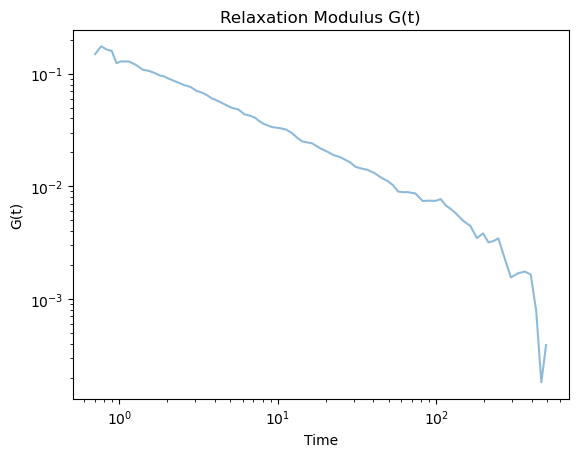

In [12]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


file = f"logs/press_50_spacing10_seed200.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
t_start = 7e-1
t_end = 5e2
# start = 0

data = data[data['time'] >= t_start]
data = data[data['time'] <= t_end]

t = data['time'].to_numpy()

G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
        (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

print("number of negative values:", np.sum(G_t < 0))
# remove negative values of G(t) from G(t) and corresponding t values
mask = G_t >= 0
t = t[mask]
G_t = G_t[mask]



G_t *= 30**3 / (1.0 * 0.6)  # V / (kB * T)

# print(data.head())
# print(G_t.min(), G_t.max())

plt.loglog(t, G_t, alpha=0.5, label='G(t) data')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t)')
plt.show()


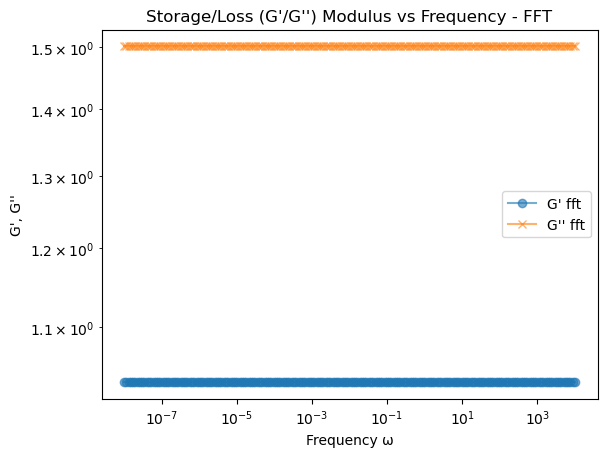

In [ ]:
# simple fourier integral calculation of G' and G'' with numpy fft

import numpy as np

n = 200
omega = np.logspace(-8, 4, n)

# Downsample G_t and t to allow for dfft

G_star = np.fft.fft(G_t)
freqs = np.fft.fftfreq(len(t), d=(t[1]-t[0]))
Gp = np.interp(omega / (2 * np.pi), freqs, G_star.real)
Gpp = np.interp(omega / (2 * np.pi), freqs, G_star.imag)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G' fft")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G'' fft")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency - FFT")
plt.legend()
plt.show()

# zero pad the end of the same length, not periodic


see fits to Maxwell modes

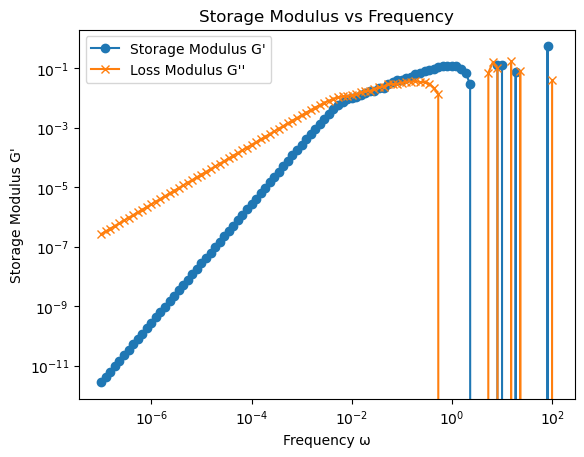

In [16]:
storage_moduli_simple_integration = []
loss_moduli_simple_integration = []

# n data points
n = 100
omega = np.logspace(-7, 2, n)

for w in omega:
    storage_moduli_simple_integration.append(storage_modulus(w, G_t, t, integration_points=5000))
    loss_moduli_simple_integration.append(loss_modulus(w, G_t, t, integration_points=5000))
    # print(f"omega: {w:.2e}, G': {storage_moduli_simple_integration[-1]:.4f}")


storage_moudili_simple_integration = np.where(np.array(storage_moduli_simple_integration) < 0, 0, np.array(storage_moduli_simple_integration))
loss_moduli_simple_integration = np.where(np.array(loss_moduli_simple_integration) < 0, 0, np.array(loss_moduli_simple_integration))


plt.loglog(omega, storage_moduli_simple_integration, marker='o', label="Storage Modulus G'")
plt.loglog(omega, loss_moduli_simple_integration, marker='x', label="Loss Modulus G''")
plt.xlabel('Frequency ω')
plt.ylabel("Storage Modulus G'")
plt.title("Storage Modulus vs Frequency")
plt.legend()
plt.show()

# storage_modulus(3, G_t, t, integration_points=5000)

This evidently does not work. Due to the large values of $\omega t$, there is a significant amount of numeric instability. 

Let's instead use the implementation here (https://arxiv.org/pdf/2203.03752, appendix A).

$$\int_0^\infty G(t) \exp(-i\omega t)dt \approx $$
$$\sum_{k=1}^N \exp(-i\omega t_{k-1}) \left\{G_k \left( \frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{\exp(-i\omega \Delta t_k)}{i\omega} \right) - G_{k-1}\left(\frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{1}{i\omega}\right)\right\}.$$

In [17]:
def integral_moduli(t, G_t, omega):
    """
    Compute the storage and loss moduli using Fourier integral from piecewise constant G(t).
    Parameters: 
    t : array_like
        Time values corresponding to G_t.
    G_t : array_like
        Relaxation modulus values at times t.
    omega : array_like
        Frequencies at which to compute the moduli.
    Returns:
    F : array_like
        Fourier transform values at frequencies omega.
    Gp : array_like
        Storage modulus values at frequencies omega.
    Gpp : array_like
        Loss modulus values at frequencies omega.
    """

    N = len(t)

In [18]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_39212/3290729079.py:4: SyntaxWarning: invalid escape sequence '\i'
  """


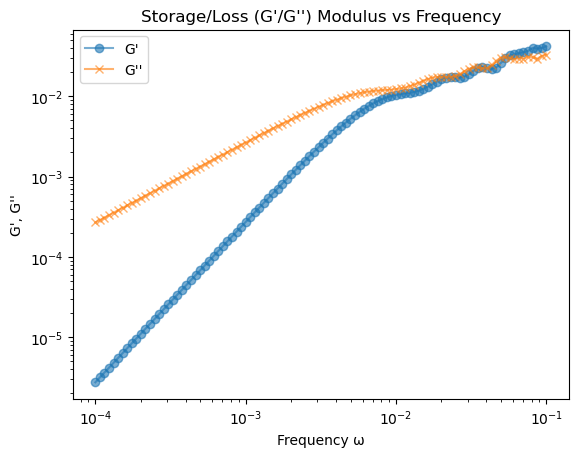

In [21]:
# n data points
n = 100
omega = np.logspace(-4, -1, n)

F, Gp, Gpp = fourier_integral_moduli(t, G_t, omega)

Gp = np.where(Gp < 0, np.nan, Gp)
Gpp = np.where(Gpp < 0, np.nan, Gpp)

# print(F)

plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
# plt.show()
# plt.loglog(omega, storage_moduli_simple_integration, marker='s', alpha=0.6, label="Storage Modulus G' (simple integration)")
# plt.loglog(omega, loss_moduli_simple_integration, marker='d', alpha=0.6, label="Loss Modulus G'' (simple integration)")

plt.legend()
plt.show()

take a look at no bonds

try with randomly placed patches (for a couple, not all of them)

different A (higher A)


# Testing simple exponential G(t) (Maxwell Model relaxation)

To verify the method above works, we will apply it to a Maxwell model (simple spring + dashpot model) and see if we get the expected storage and loss moduli.

The dynamic modulus of a simple Maxwell model is an exponential, with the form

$$G(t) = k e^{-\frac k \eta t}$$

and examining it in comparison to the expected form (https://pubs.rsc.org/en/content/articlehtml/2020/sm/d0sm00354a, Fig. 2)

False
Maxwell model G(t) min, max: 0.0 100.0


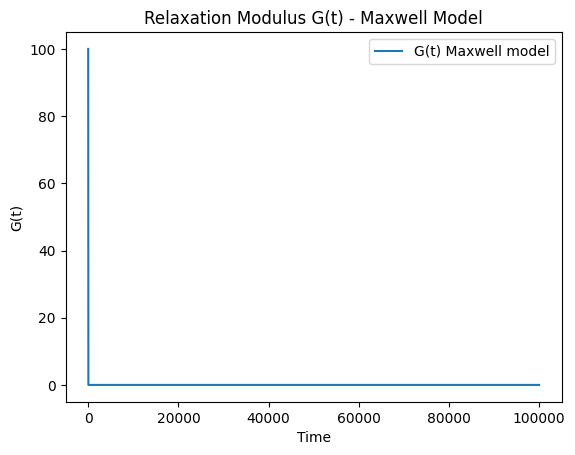

In [134]:
# Test of moduli function using a Maxwell model G(t) = k * exp(- (k/eta) * t)

k = 1e2
eta = 1.0
t = np.linspace(0, 1e5, 5000)
G_t = k * np.exp(- (k / eta) * t)

print(np.any(~np.isfinite(G_t))) # should be False
print("Maxwell model G(t) min, max:", G_t.min(), G_t.max())

# plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.plot(t, G_t , label='G(t) Maxwell model')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t) - Maxwell Model')
plt.legend()
plt.show()



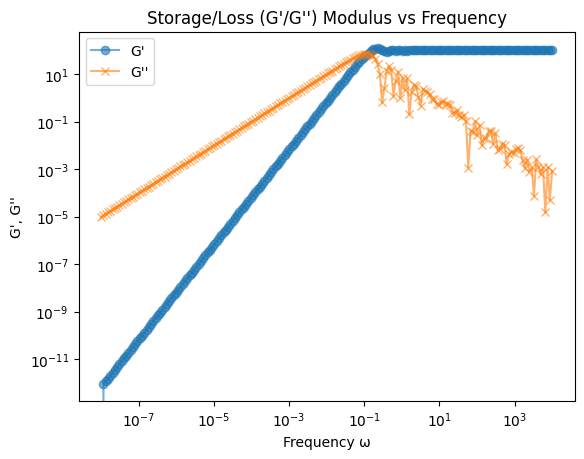

In [137]:

# n data points
n = 200
omega = np.logspace(-8, 4, n)
F, Gp, Gpp = fourier_integral_moduli(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


number of negative values: 0


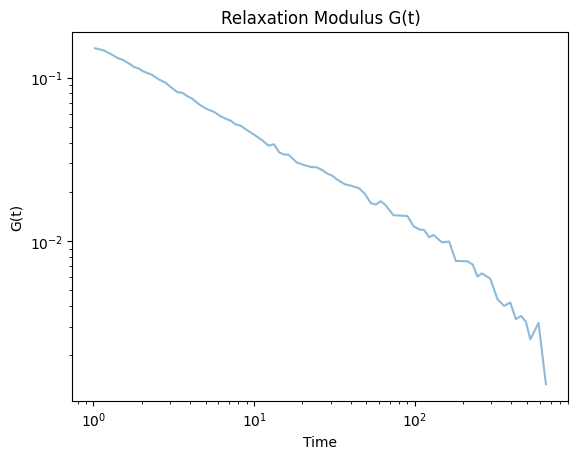

Fitted parameters: k = 0.1444, eta = 0.7997, offset = -0.0139


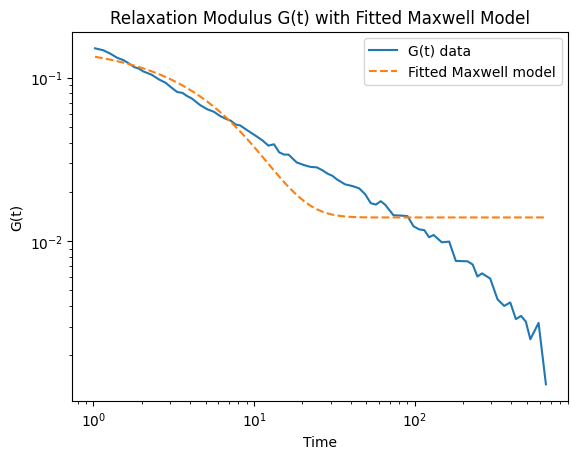

In [153]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


file = f"logs/press_50_spacing4_seed200.dat"
data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
start = 64
end = 139
# start = 0

data = data[start:end].reset_index(drop=True)

t = data['time'].to_numpy()

G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
        (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

# replace negative with NaN
print("number of negative values:", np.sum(G_t < 0))


G_t *= 30**3 / (1.0 * 0.6)  # V / (kB * T)

# print(data.head())
# print(G_t.min(), G_t.max())

plt.loglog(t, G_t, alpha=0.5, label='G(t) data')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t)')
plt.show()


# fit exponential decay to G(t) data to get k and eta
from scipy.optimize import curve_fit
def maxwell_model(t, k, eta, offset=0):
    return k * np.exp(- (k / eta) * t) - offset
popt, pcov = curve_fit(maxwell_model, t, G_t, p0=(0.027,1, 0.0))
k_fit, eta_fit, offset_fit = popt
print(f"Fitted parameters: k = {k_fit:.4f}, eta = {eta_fit:.4f}, offset = {offset_fit:.4f}")

plt.plot(t, G_t, label='G(t) data')
# plt.show()
plt.loglog(t, maxwell_model(t, k_fit, eta_fit, offset_fit), label='Fitted Maxwell model', linestyle='--')
# plt.plot(t, maxwell_model(t, 0.027, 1, 0), label='Fitted Maxwell model', linestyle='--')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t) with Fitted Maxwell Model')
plt.legend()
plt.show()

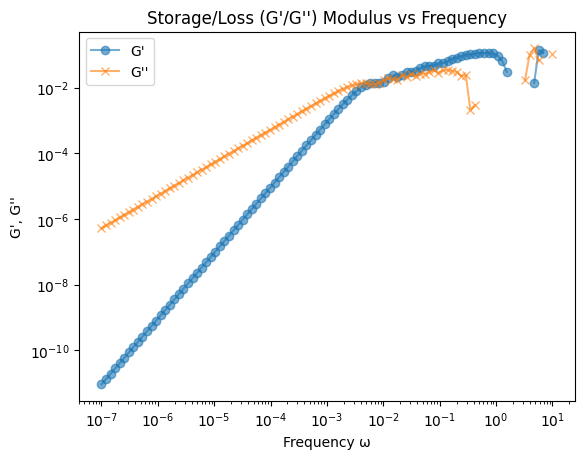

In [154]:
# n data points
n = 100
omega = np.logspace(-7, 1, n)

F, Gp, Gpp = fourier_integral_moduli(t, G_t, omega)

Gp = np.where(Gp < 0, np.nan, Gp)
Gpp = np.where(Gpp < 0, np.nan, Gpp)

# print(F)

plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
# plt.show()
# plt.loglog(omega, storage_moduli_simple_integration, marker='s', alpha=0.6, label="Storage Modulus G' (simple integration)")
# plt.loglog(omega, loss_moduli_simple_integration, marker='d', alpha=0.6, label="Loss Modulus G'' (simple integration)")

plt.legend()
plt.show()

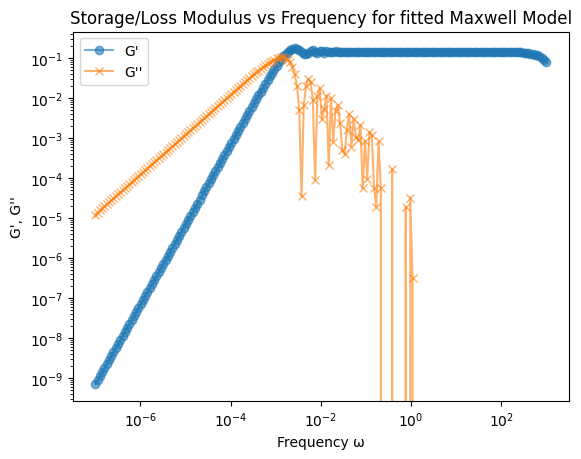

In [158]:
# fit to optimized k and eta
k = k_fit
eta = eta_fit
offset = offset_fit
t = np.linspace(1e-3, 1e5, 60)

G_t_fit = maxwell_model(t, k, eta, 0)


# n data points
n = 200
omega = np.logspace(-7, 3, n)
F, Gp, Gpp = fourier_integral_moduli(t, G_t_fit, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss Modulus vs Frequency for fitted Maxwell Model")
plt.legend()
plt.show()



Comparing the G'/G'' plots with the plots of our actual data

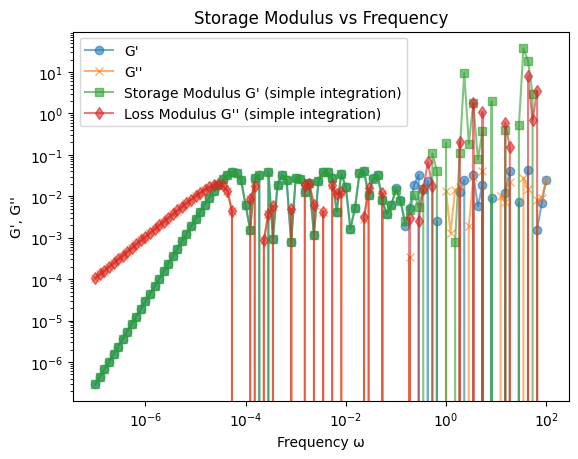

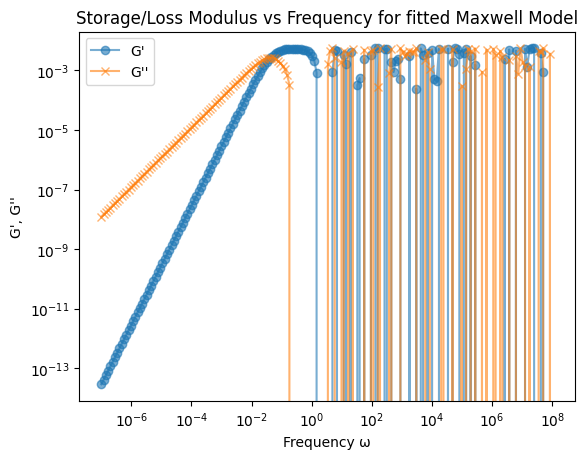